exercice 5 ML: 

In [2]:
from sklearn.datasets import fetch_california_housing  
import pandas as pd 
import numpy as np
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names) 
df["MedHouseVal"] = data.target 


1. Exploration basique 

In [6]:
print("nombre de ligne et colonnes :",df.shape)
print("noms des colonnes :",df.columns)
print("types de données :",df.dtypes)
print("ValueErrors :",df.isnull().sum())

nombre de ligne et colonnes : (20640, 9)
noms des colonnes : Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')
types de données : MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object
ValueErrors : MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


2. statistiques descriptives

In [7]:
print("la moyenne du pric des maisons : ",df["MedHouseVal"].mean())
print("l'age moyen des maisons : ",df["HouseAge"].mean())
print("la valeur minimale pour chaque feature : \n",df.min())
print("la valeur maximale pour chaque feature : \n",df.max())
print("l'ecart type de chaque variable numérique : ",df.std())


la moyenne du pric des maisons :  2.068558169089147
l'age moyen des maisons :  28.639486434108527
la valeur minimale pour chaque feature : 
 MedInc           0.499900
HouseAge         1.000000
AveRooms         0.846154
AveBedrms        0.333333
Population       3.000000
AveOccup         0.692308
Latitude        32.540000
Longitude     -124.350000
MedHouseVal      0.149990
dtype: float64
la valeur maximale pour chaque feature : 
 MedInc            15.000100
HouseAge          52.000000
AveRooms         141.909091
AveBedrms         34.066667
Population     35682.000000
AveOccup        1243.333333
Latitude          41.950000
Longitude       -114.310000
MedHouseVal        5.000010
dtype: float64
l'ecart type de chaque variable numérique :  MedInc            1.899822
HouseAge         12.585558
AveRooms          2.474173
AveBedrms         0.473911
Population     1132.462122
AveOccup         10.386050
Latitude          2.135952
Longitude         2.003532
MedHouseVal       1.153956
dtype: float

3. visualisation simple

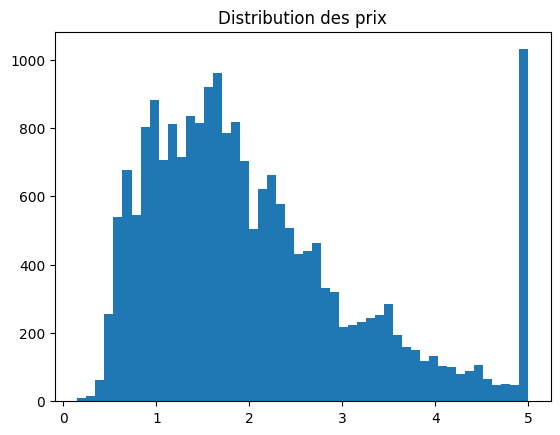

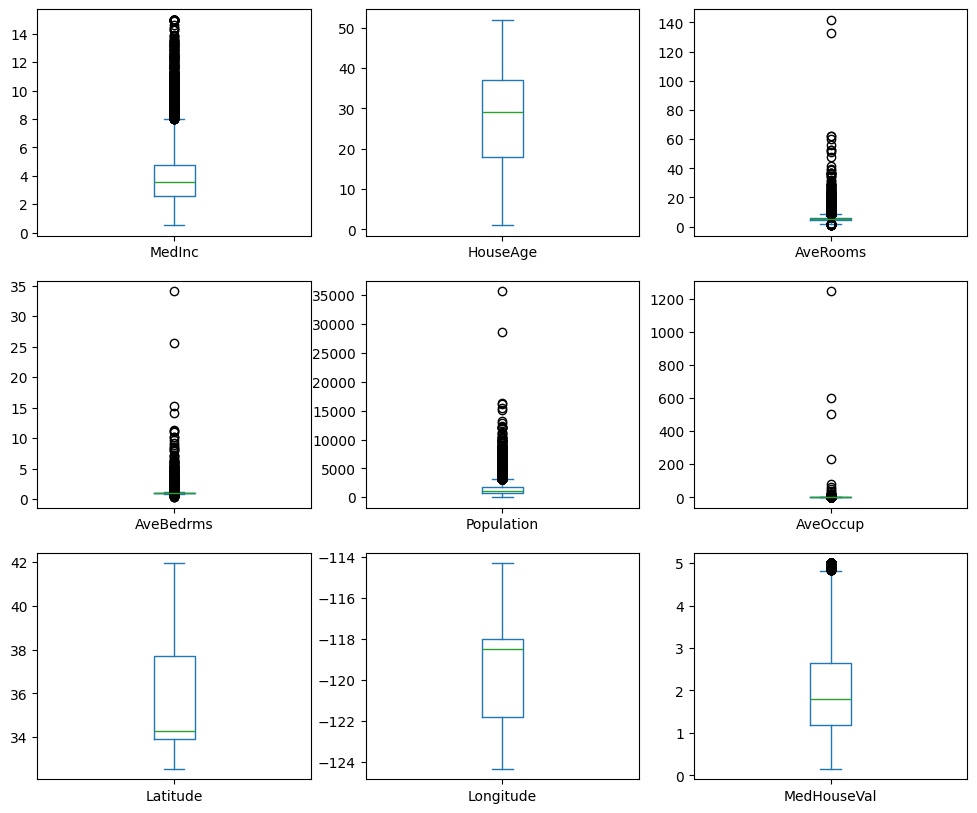

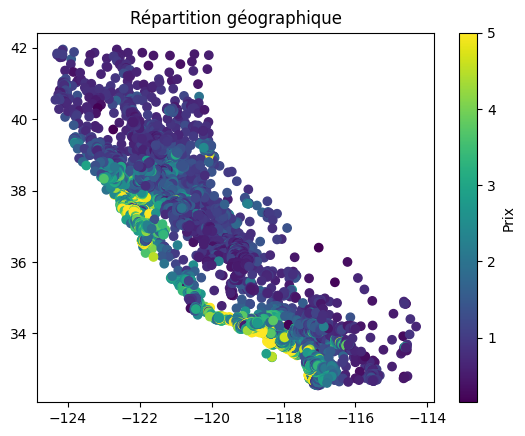

In [9]:
import matplotlib.pyplot as plt
# Histogramme des prix
plt.hist(df["MedHouseVal"], bins=50)
plt.title("Distribution des prix")
plt.show()

# Boxplot
df.plot(kind='box', subplots=True, layout=(3,3), figsize=(12,10))
plt.show()

# Carte géographique
plt.scatter(df["Longitude"], df["Latitude"], c=df["MedHouseVal"], cmap="viridis")
plt.colorbar(label="Prix")
plt.title("Répartition géographique")
plt.show()

4. analyse des relations

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64
Top features : MedInc      0.688075
AveRooms    0.151948
Latitude    0.144160
Name: MedHouseVal, dtype: float64


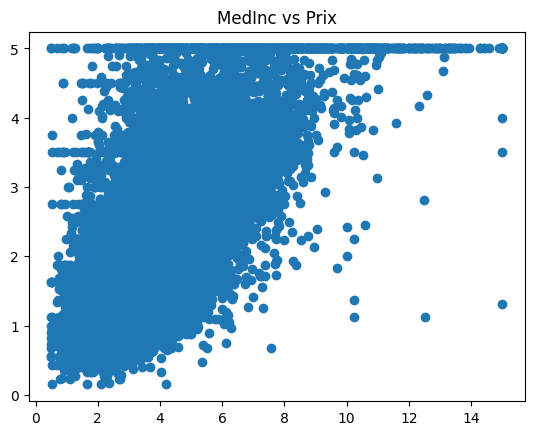

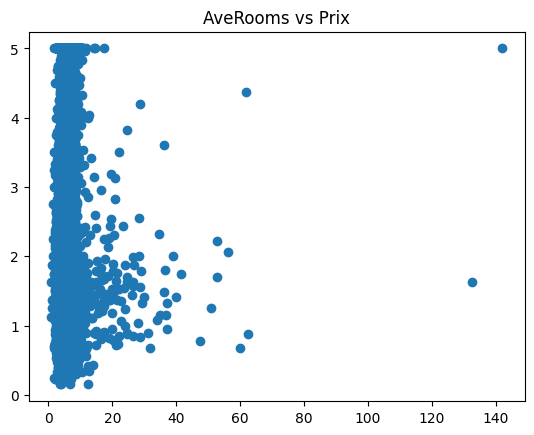

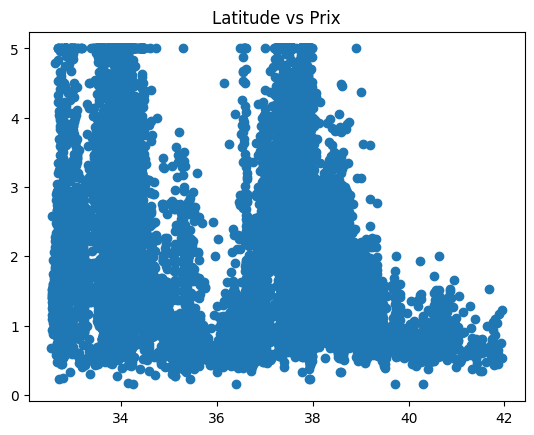

In [10]:
# Calcul de la corrélation entre toutes les variables numériques 
corr = df.corr()
print(corr["MedHouseVal"].sort_values(ascending=False))

# Identification des 3 features corrélées avec le prix
top_features = corr["MedHouseVal"].abs().sort_values(ascending=False)[1:4]
print("Top features :", top_features)

# Création de scatter plots entre le prix et ces features
for col in top_features.index:
    plt.scatter(df[col], df["MedHouseVal"])
    plt.title(f"{col} vs Prix")
    plt.show()

5. analyse des distributions

In [ ]:
# Calcul de la skewness pour chaque variable numérique
print("Skewness :")
print(df.skew())

# Histogrammes
df.hist(figsize=(12,10))
plt.show()

6. filtrage et agregation

In [23]:
# groupement des données par regions et calcule du prix moyen
df["Region"] = pd.cut(df["Latitude"], bins=3, labels=["Sud", "Centre", "Nord"])
prix_moyen_par_region = df.groupby("Region")["MedHouseVal"].mean()
print("prix moyen par région :", prix_moyen_par_region)

#filtrage des maisons dont le prix est supérieur à la moyenne
moy = df[df["MedHouseVal"] > df["MedHouseVal"].mean()]
print("maisons avec un prix supérieur à la moyenne : ", moy)

#identification des zones les plus chères et les moins chères
print("zones les plus chères et les moins chères : ", df.groupby("Region")["MedHouseVal"].mean().sort_values())

prix moyen par région : Region
Sud       2.172686
Centre    2.067532
Nord      1.020560
Name: MedHouseVal, dtype: float64
maisons avec un prix supérieur à la moyenne :         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20544  2.0650      23.0  4.803493   1.013646      6330.0  3.455240     38.55   
20545  3.7452      26.0  5.113951   1.011715      2199.0  2.341853     38.55   
20565  2.4167      22.0  5.938865   1.231441       808.0  3.528384     38.65   
20573  5.6790      20.0  6.4012

C:\Users\DALIDATECH\AppData\Local\Temp\ipykernel_26004\4251622978.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prix_moyen_par_region = df.groupby("Region")["MedHouseVal"].mean()
C:\Users\DALIDATECH\AppData\Local\Temp\ipykernel_26004\4251622978.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print("zones les plus chères et les moins chères : ", df.groupby("Region")["MedHouseVal"].mean().sort_values())


7. detection des anomalies

In [21]:
from scipy.stats import zscore
#utilisation de la methode IQR pour detecter les outliers
Q1 = df.select_dtypes(include=[np.number]).quantile(0.25)
Q3 = df.select_dtypes(include=[np.number]).quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df.select_dtypes(include=[np.number]) < (Q1 - 1.5 * IQR)) |
              (df.select_dtypes(include=[np.number]) > (Q3 + 1.5 * IQR))]

#Calcul des z-scores pour chaque variable 
z_scores = np.abs(zscore(df.select_dtypes(include=[np.number])))

8. Creation de features

In [22]:
# Creation d'un ratio prix/surface
df["Rooms_per_household"] = df["AveRooms"] / df["AveOccup"]

# Discrétisation des variables continues en  catégories
df["Income_cat"] = pd.cut(df["MedInc"], bins=5)

# Autres features
df["Population_per_household"] = df["Population"] / df["AveOccup"]

9. analyse approfondie

In [24]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = df.select_dtypes(include=[np.number]).drop(columns=["MedHouseVal"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Variance expliquée :", pca.explained_variance_ratio_)

Variance expliquée : [0.28413427 0.21730633]
